## Objective Project
Analyze sales and inventory data to find insights that can improve sales and stock efficiency.

## Import Library

In [1]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt

## Kernel Config & Load Data

**Use Kernel from Google Colab**
- Select Kernel by click Kernel option at top right side
- click **Select Another Kernel**
- click **Colab**
- click **Auto Connect**
- click **Python 3 (ipykernel)**
- right click file 'train.csv' then select **Upload to Colab**
- wait until message pop up at left bottom corner **Successfully uploaded 1 item to Colab CPU**

In [2]:
# Load Data
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Understanding

In [3]:
# Data Understanding by show dataset size, configuration, 
print("# Show Dataset Size\n-------------------\nDataset size: %d rows and %d columns\n" % df.shape)

print('# Show configuration of dataset\n-------------------------------')
df.info()

print('\n# Show all column\n-----------------')
df.columns

# Show Dataset Size
-------------------
Dataset size: 9800 rows and 18 columns

# Show configuration of dataset
-------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [4]:
# show summary statistic of dataset for understanding dataset
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
# Show null numbers of each column in dataset
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Insight :**<br>

As long as *Postal Code* is not used in the main analysis such as sales value and product performance,<br>
missing values in this column *(Postal Code)* do not have a significant impact on the analysis results.

**Dataset Overview**
- The dataset has 9800 rows and 18 columns
- There are columns such as Sales, Profit, Category, Order Date, etc

**Data Quality**
- There are no/missing values in certain columns
- Data type is corrett / needs conversion

## Data Cleaning
This step was taken to remove duplicate data to avoid bias in the analysis,<br>because duplication can cause sales calculations to be inaccurate.

In [6]:
# Duplicate value check
df.duplicated().sum()

np.int64(0)

**Note :** There is not duplicate value

In [7]:
df.duplicated(subset=['Order ID']).sum()

np.int64(4878)

**Note :** This duplication is normal, because one *Order ID* use for many transaction of *Product ID*

**Note :** *Order Date* column is converted to datetime format so that it can be used for time trend analysis.

In [8]:
# change data type of Order Date column
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# change data type of Ship Date column
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# show config of dataset after column Order Date and Ship Date change to Datetime format
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

## Exploratory Data Analysis (EDA)

<Axes: xlabel='Order Date'>

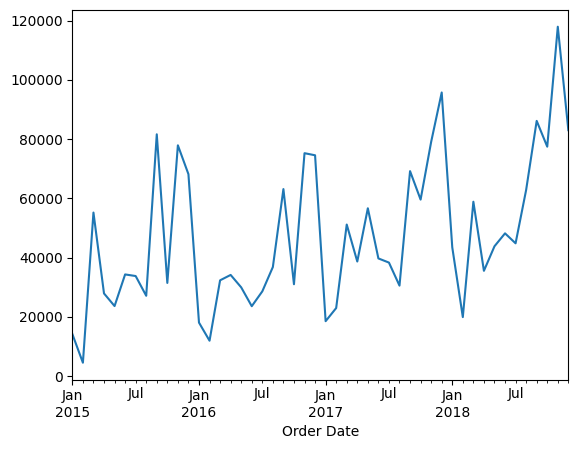

In [9]:
# create monthly sales summary by counting sales qty by Order Date column
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot()

**Insight :**

Fluctuations may be caused by seasonal factors, spesific promotions, or sales events that<br>
increase during certain periods.

Furthermore, variations in demand berween products can also contribute to sales imbalances between months.

High Fluctuations indicate that inventory strategies must be adaptive,<br>
as demand is not consistent each month.

In [10]:
# create new variable top_product for check best seller product
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# create new variable low_product for check not moving product
low_products = df.groupby('Product Name')['Sales'].sum().sort_values().head(10)

In [11]:
# create new variable category_sales for check highest qty sales by category (category analysis)
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


In [12]:
# show best seller product
top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


**Insight :**<br>

For high-performance products, companies need to ensure optimal stock availability<br>
to avoid missing sales opportunities, especially during periods of high demand.

In [13]:
# show bad performance sales product (potential dead stock)
low_products

,Sales
Product Name,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624
Avery 5,5.760
Xerox 20,6.480
Grip Seal Envelopes,7.072
Acme Serrated Blade Letter Opener,7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800
Xerox 1989,7.968
4009 Highlighters,8.040


**Insight :**<br>


This product has the potential to become dead stock if no action is taken<br>
such as promotion of product sustainability evaluation.

In addition, companies can also optimize inventory allocation by reducing purchases of<br>
slow-moving products and allocating budgets to fast-moving products.

In [14]:
# show top 10 summary data qty sales by month of order date
monthly_sales.head(10)

,Sales
Order Date,
2015-01,14205.7070
2015-02,4519.8920
2015-03,55205.7970
2015-04,27906.8550
2015-05,23644.3030
2015-06,34322.9356
2015-07,33781.5430
2015-08,27117.5365
2015-09,81623.5268


In [15]:
# dead stock analysis (game changer)
product_sales = df.groupby('Product Name')['Sales'].sum()
dead_stock = product_sales[product_sales < product_sales.quantile(0.25)]
dead_stock.head(10)

,Sales
Product Name,
"""While you Were Out"" Message Book, One Form per Page",25.228
"#10 Gummed Flap White Envelopes, 100/Box",41.300
#6 3/4 Gummed Flap White Envelopes,71.280
"1/4 Fold Party Design Invitations & White Envelopes, 24 8-1/2"" X 11"" Cards, 25 Env./Pack",49.980
12 Colored Short Pencils,18.200
3-ring staple pack,42.112
3M Organizer Strips,83.160
4009 Highlighters,8.040
ACCOHIDE Binder by Acco,65.254


**Insight :**<br>

Products that are classified as dead stock can cause inventory inefficiencies, because<br>
they incur storage costs and tie up capital that could be allocated to higher-performance products.

In addition, this can also reduce the company's overall profitability.

In [16]:
# use moving average for forcasting and stock prediction
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
forecast_ma = monthly_sales.rolling(window=3).mean()
forecast_next_month = forecast_ma.iloc[-1]
print('Sales prediction for next month:', forecast_next_month)

Sales prediction for next month: 92805.55833333333


In [17]:
# sum of forcast
forcast_value = monthly_sales.rolling(window=3).mean().iloc[-1]

In [18]:
# Moving average (trend)
moving_avg = monthly_sales.rolling(window=3).mean()

# Forecast next month
forecast_value = moving_avg.iloc[-1]

# Tambah periode baru
last_period = monthly_sales.index[-1]
next_period = last_period + 1

# DataFrame gabungan
df_plot = pd.DataFrame({
    'Actual': monthly_sales,
    'Moving Avg': moving_avg
})

# Tambahkan forecast
df_plot.loc[next_period] = [None, None]
df_plot.loc[next_period, 'Forecast'] = forecast_value

/tmp/ipykernel_9592/291043517.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_plot.loc[next_period] = [None, None]


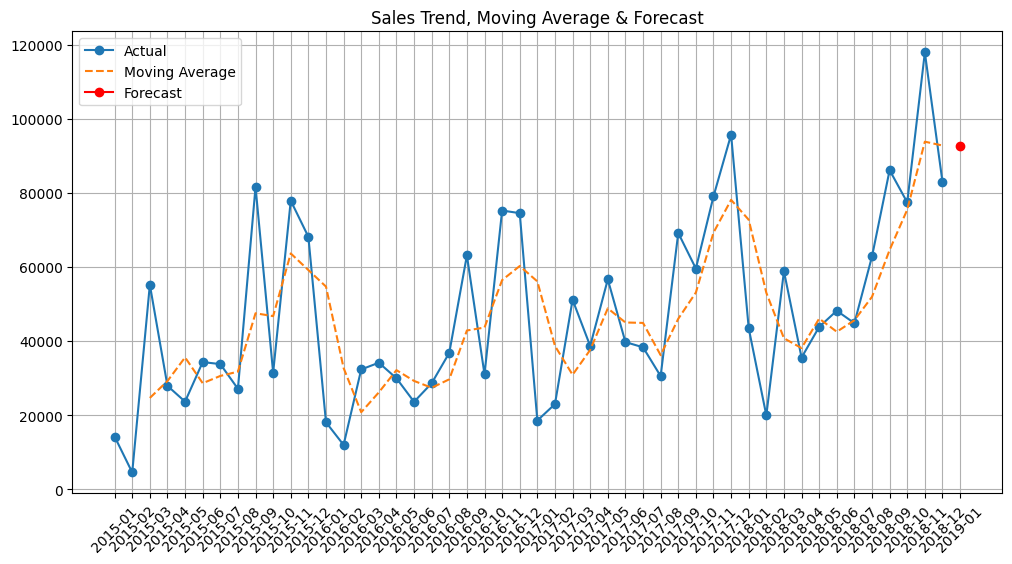

In [19]:

plt.figure(figsize=(12,6))

# Actual
plt.plot(df_plot.index.astype(str), df_plot['Actual'], marker='o', label='Actual')

# Moving Average
plt.plot(df_plot.index.astype(str), df_plot['Moving Avg'], linestyle='--', label='Moving Average')

# Forecast (titik terakhir)
plt.plot(df_plot.index.astype(str), df_plot['Forecast'], marker='o', color='red', label='Forecast')

plt.xticks(rotation=45)
plt.legend()
plt.title("Sales Trend, Moving Average & Forecast")
plt.grid()

plt.show()

**Note :**<br>
I use moving averages to look at historical trends, and use the last value of that<br>
moving average as a basis for predicting next month's sales.

**Prediction by Moving Average :**<br>

Based on the moving average calculation from the last 3 months, sales for the following month<br>
are predicted to be within a certain range that reflects the latest trend from historical data

The approach is used to reduce short-term fluctuations and provide more stable estimates as a<br>
basis for business planning.

## The most effective strategy to overcome dead stock
1. Promote or bundle with fast-moving products to increase visibility and sales.
2. Reduce purchases of the product in the next period to avoid overstock.
3. Evaluate whether the product is still relevant to market needs.
4. Optimize inventory allocation by shifting budget to high-performance products.